In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt

pd.set_option('display.max_rows', None)

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 20_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_35461/4272977193.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [ ]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.709999,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   event_time     20000 non-null  object  
 1   event_type     20000 non-null  category
 2   product_id     20000 non-null  int32   
 3   category_id    20000 non-null  int64   
 4   category_code  13412 non-null  category
 5   brand          17185 non-null  category
 6   price          20000 non-null  float32 
 7   user_id        20000 non-null  int32   
 8   user_session   20000 non-null  object  
dtypes: category(3), float32(1), int32(2), int64(1), object(2)
memory usage: 826.0+ KB


In [6]:
shape_df = df.shape

In [7]:
df.isnull().sum()/shape_df[0]

event_time       0.00000
event_type       0.00000
product_id       0.00000
category_id      0.00000
category_code    0.32940
brand            0.14075
price            0.00000
user_id          0.00000
user_session     0.00000
dtype: float64

In [8]:
df['product_id'].nunique()

7178

In [9]:
df['event_type'].nunique()

3

In [10]:
df['event_type'].value_counts(normalize = True)

event_type
view        0.9774
purchase    0.0129
cart        0.0097
Name: proportion, dtype: float64

In [10]:
df.groupby(df['user_id'])['product_id'].count()

user_id
306441847    1
372944259    2
400972610    5
428099415    3
434894256    2
            ..
555467129    2
555467157    1
555467172    1
555467188    1
555467192    1
Name: product_id, Length: 5012, dtype: int64

In [11]:
df['user_id'].nunique()

5012

<Axes: >

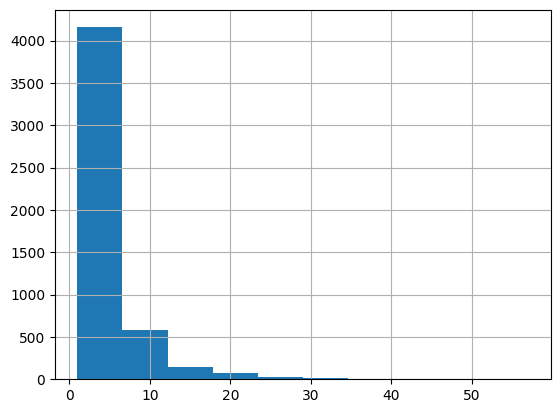

In [12]:
df.groupby(df['user_id'])['user_session'].count().hist()

In [13]:
df['user_session'].nunique()

5669

In [37]:
df['product_id'].nunique()

7178

In [ ]:
df['user_id'].nunique()

5012

In [ ]:
df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


/tmp/ipykernel_8805/2700003842.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [ ]:
df_phone = df[df['category_code']=='electronics.smartphone']

In [23]:
df_phone.shape

(5387, 9)

In [24]:
df_phone['event_type'].value_counts(normalize = True)

event_type
view        0.950065
cart        0.027102
purchase    0.022833
Name: proportion, dtype: float64

In [42]:
df_na = df[df['category_code'].isna()==True]

In [43]:
df_na.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
13,2019-10-01 00:00:15 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
15,2019-10-01 00:00:17 UTC,view,23100006,2053013561638126333,NaN,NaN,357.790009,513642368,17566c27-0a8f-4506-9f30-c6a2ccbf583b


In [51]:
df_na.shape

(6588, 9)

In [46]:
df_na['event_type'].value_counts()


event_type
view        6511
purchase      58
cart          19
Name: count, dtype: int64

In [3]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone'
'electronics.clocks'
'computers.notebook'
'electronics.video.tv']


In [4]:
df_elec=df[df['category_code'].isin(list_category_code)==True]

In [6]:
df_elec.shape

(5387, 9)

In [7]:
df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])

/tmp/ipykernel_2768/1338302109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])


In [8]:
df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])

/tmp/ipykernel_2768/507844041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])


In [62]:
df_elec.shape

(5387, 11)

In [63]:
df_elec.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:04
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,2019-10-01,00:00:11
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,2019-10-01,00:00:11
19,2019-10-01 00:00:19 UTC,view,1005135,2053013555631882655,electronics.smartphone,apple,1747.790039,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:19
20,2019-10-01 00:00:20 UTC,view,1003306,2053013555631882655,electronics.smartphone,apple,588.770020,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,2019-10-01,00:00:20


In [ ]:

df_elec['date'] = pd.to_datetime(df_elec['date'])

/tmp/ipykernel_2768/2743374563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['date'] = pd.to_datetime(df_elec['date'])


In [ ]:
df_elec['week_of_day'] = df_elec['date'].dt.day_name()

/tmp/ipykernel_33673/3461437742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['week_of_day'] = df_elec['date'].dt.day_name()


In [ ]:
df_elec.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour,week_of_day
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:04,Tuesday
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,2019-10-01,00:00:11,Tuesday
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,2019-10-01,00:00:11,Tuesday
19,2019-10-01 00:00:19 UTC,view,1005135,2053013555631882655,electronics.smartphone,apple,1747.790039,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,00:00:19,Tuesday
20,2019-10-01 00:00:20 UTC,view,1003306,2053013555631882655,electronics.smartphone,apple,588.770020,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,2019-10-01,00:00:20,Tuesday


<Axes: >

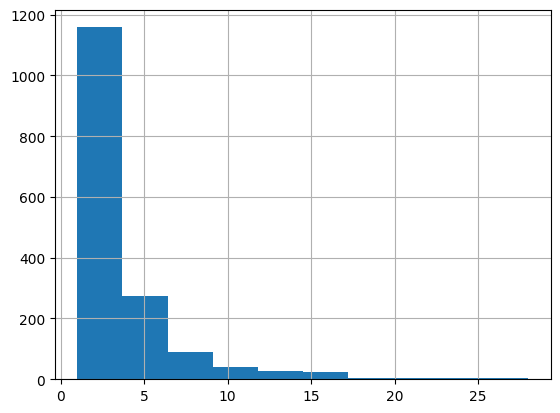

In [ ]:
df_elec.groupby('user_id')['event_type'].count().hist()

In [84]:
df_aux = df_elec[df_elec['event_type']=='view']

In [93]:
df_aux.groupby('user_id').count().mean()

event_time       3.141805
event_type       3.141805
product_id       3.141805
category_id      3.141805
category_code    3.141805
brand            3.138122
price            3.141805
user_session     3.141805
date             3.141805
hour             3.141805
week_of_day      3.141805
dtype: float64

In [91]:
df_aux.groupby('user_id').count().max()

event_time       28
event_type       28
product_id       28
category_id      28
category_code    28
brand            28
price            28
user_session     28
date             28
hour             28
week_of_day      28
dtype: int64

In [92]:
df_aux.groupby('user_id').count().std()

event_time       3.442066
event_type       3.442066
product_id       3.442066
category_id      3.442066
category_code    3.442066
brand            3.439538
price            3.442066
user_session     3.442066
date             3.442066
hour             3.442066
week_of_day      3.442066
dtype: float64

In [ ]:
df_aux.groupby('user_session').count().std()

In [10]:
df_elec = df_elec.sort_values(by = ['user_id', 'user_session','event_time'])
df_elec.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour
14918,2019-10-01 02:45:49 UTC,view,1005100,2053013555631882655,electronics.smartphone,samsung,154.419998,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,2019-10-01,02:45:49
16180,2019-10-01 02:48:02 UTC,view,1004750,2053013555631882655,electronics.smartphone,samsung,197.429993,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,2019-10-01,02:48:02
1097,2019-10-01 01:06:56 UTC,view,1004839,2053013555631882655,electronics.smartphone,oppo,179.389999,477121012,413b498a-71d5-49fa-b896-1761ab981917,2019-10-01,01:06:56
2866,2019-10-01 02:23:15 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,2019-10-01,02:23:15
2982,2019-10-01 02:23:34 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,2019-10-01,02:23:34
3002,2019-10-01 02:23:39 UTC,view,1002544,2053013555631882655,electronics.smartphone,apple,464.130005,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,2019-10-01,02:23:39
18124,2019-10-01 02:51:06 UTC,view,1004144,2053013555631882655,electronics.smartphone,xiaomi,128.380005,489294047,0282c875-832f-49fb-888d-0094fad7990a,2019-10-01,02:51:06
18730,2019-10-01 02:52:03 UTC,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,103.080002,489294047,0282c875-832f-49fb-888d-0094fad7990a,2019-10-01,02:52:03
18966,2019-10-01 02:52:23 UTC,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,103.080002,489294047,0282c875-832f-49fb-888d-0094fad7990a,2019-10-01,02:52:23
19552,2019-10-01 02:53:16 UTC,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,103.080002,489294047,0282c875-832f-49fb-888d-0094fad7990a,2019-10-01,02:53:16


In [ ]:
#df_elec['event_type_str'] = df_elec['event_type'].astype(str)
#df_events = df_elec.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(11)
#               ], index=['event1', 'event2', 'event3','event4', 'event5', 'event6','event7', 'event8', 'event9','event10', 'event11' ])).reset_index()
#df_events.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str')
#df_events.head(10)

In [ ]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_35461/3014714917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_35461/3014714917.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [9]:
df_events = df_elec.groupby(['user_id', 'user_session', 'product_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : x.max() - x.min()),
}).reset_index()

In [10]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,event_time
0,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00
1,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00
2,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00
3,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24
4,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00
5,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39
6,500521935,edd22068-ddc8-4bb1-ba72-26368054819a,1004870,view view,0 days 00:11:22
7,503712613,f04ce684-ce44-4150-b3dd-bb6999d1007b,1004249,view view,0 days 00:00:39
8,504386888,a52bff68-17aa-4f4c-b323-328e66418a11,1002544,view,0 days 00:00:00
9,507564181,7a7701c6-6d17-4e9a-a32a-06d1d61972e3,1005100,view,0 days 00:00:00


In [12]:
df_events = df_events.rename(columns={'event_time':'duration'})

In [13]:
df_events['event_type_str'].value_counts()/df_events.shape[0]


event_type_str
view                                                    0.689385
view view                                               0.196648
view view view                                          0.044693
view view view view                                     0.015084
view view view view view                                0.005587
view purchase view                                      0.005028
view cart purchase view                                 0.004190
view cart purchase                                      0.003631
view cart                                               0.003073
view cart view                                          0.002793
view purchase                                           0.002793
view purchase view view                                 0.001955
view view cart view                                     0.001676
view view purchase                                      0.001676
view view cart                                          0.001397
view view 

In [56]:
df_events.shape

(3580, 4)

In [14]:
df_events['y']=df_events['event_type_str'].str.contains("purchase").apply(lambda x : int(x))

In [15]:
df_events.head(100)

,user_id,user_session,product_id,event_type_str,duration,y
0,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0
1,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0
2,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0
3,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0
4,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0
5,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0
6,500521935,edd22068-ddc8-4bb1-ba72-26368054819a,1004870,view view,0 days 00:11:22,0
7,503712613,f04ce684-ce44-4150-b3dd-bb6999d1007b,1004249,view view,0 days 00:00:39,0
8,504386888,a52bff68-17aa-4f4c-b323-328e66418a11,1002544,view,0 days 00:00:00,0
9,507564181,7a7701c6-6d17-4e9a-a32a-06d1d61972e3,1005100,view,0 days 00:00:00,0


In [108]:
df_events['y'].value_counts()

y
0    3464
1     116
Name: count, dtype: int64

In [16]:
df_events['event_len'] = df_events['event_type_str'].apply(lambda x : len(x.split()))

In [17]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,duration,y,event_len
0,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0,1
1,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0,1
2,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0,1
3,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3
4,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0,1
5,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0,5
6,500521935,edd22068-ddc8-4bb1-ba72-26368054819a,1004870,view view,0 days 00:11:22,0,2
7,503712613,f04ce684-ce44-4150-b3dd-bb6999d1007b,1004249,view view,0 days 00:00:39,0,2
8,504386888,a52bff68-17aa-4f4c-b323-328e66418a11,1002544,view,0 days 00:00:00,0,1
9,507564181,7a7701c6-6d17-4e9a-a32a-06d1d61972e3,1005100,view,0 days 00:00:00,0,1


In [18]:
df_events.describe()

,user_id,product_id,duration,y,event_len
count,3.580000e+03,3.580000e+03,3580,3580.000000,3580.000000
mean,5.331477e+08,1.004527e+06,0 days 00:00:37.814245810,0.032402,1.504749
std,1.654537e+07,7.065995e+02,0 days 00:02:00.622539365,0.177091,0.970783
min,4.449901e+08,1.002098e+06,0 days 00:00:00,0.000000,1.000000
25%,5.165312e+08,1.004250e+06,0 days 00:00:00,0.000000,1.000000
50%,5.316601e+08,1.004788e+06,0 days 00:00:00,0.000000,1.000000
75%,5.504211e+08,1.005003e+06,0 days 00:00:22.250000,0.000000,2.000000
max,5.554672e+08,1.005171e+06,0 days 00:30:40,1.000000,9.000000


In [ ]:
df_events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3580 entries, 0 to 3579
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_id         3580 non-null   int32          
 1   user_session    3580 non-null   object         
 2   product_id      3580 non-null   int32          
 3   event_type_str  3580 non-null   object         
 4   duration        3580 non-null   timedelta64[ns]
 5   y               3580 non-null   int64          
 6   event_len       3580 non-null   int64          
dtypes: int32(2), int64(2), object(2), timedelta64[ns](1)
memory usage: 167.9+ KB


In [21]:
df_events['duration_mean']=df_events['duration']/df_events['event_len']

In [ ]:
df_events.head(10)

,user_id,user_session,product_id,event_type_str,duration,y,event_len,duration_mean
0,444990139,3aa0ea60-72b9-4c7f-9471-edaafb7a71a7,1005100,view,0 days 00:00:00,0,1,0 days 00:00:00
1,463389113,946d3372-5af2-4a5a-b30b-ef7eef464fba,1004750,view,0 days 00:00:00,0,1,0 days 00:00:00
2,477121012,413b498a-71d5-49fa-b896-1761ab981917,1004839,view,0 days 00:00:00,0,1,0 days 00:00:00
3,479233261,44dd8d4a-5fa0-44a8-9729-4720cb8cc98f,1002544,view view view,0 days 00:00:24,0,3,0 days 00:00:08
4,489294047,0282c875-832f-49fb-888d-0094fad7990a,1004144,view,0 days 00:00:00,0,1,0 days 00:00:00
5,489294047,0282c875-832f-49fb-888d-0094fad7990a,1005008,view view view view view,0 days 00:01:39,0,5,0 days 00:00:19.800000
6,500521935,edd22068-ddc8-4bb1-ba72-26368054819a,1004870,view view,0 days 00:11:22,0,2,0 days 00:05:41
7,503712613,f04ce684-ce44-4150-b3dd-bb6999d1007b,1004249,view view,0 days 00:00:39,0,2,0 days 00:00:19.500000
8,504386888,a52bff68-17aa-4f4c-b323-328e66418a11,1002544,view,0 days 00:00:00,0,1,0 days 00:00:00
9,507564181,7a7701c6-6d17-4e9a-a32a-06d1d61972e3,1005100,view,0 days 00:00:00,0,1,0 days 00:00:00


,y,event_len
0,0,"Axes(0.125,0.11;0.775x0.77)"
1,1,"Axes(0.125,0.11;0.775x0.77)"


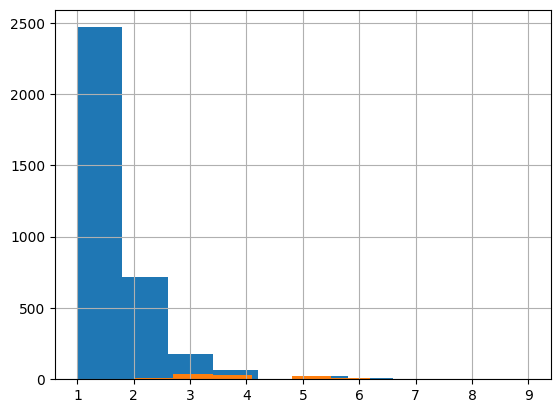

In [111]:
df_events.groupby(df_events['y'], as_index=False)['event_len'].hist()

In [112]:
df_events['event_len'].describe()

count    3580.000000
mean        1.504749
std         0.970783
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: event_len, dtype: float64